In [ ]:
print("Voice-Based Resume Keyword Analyzer")
print("Project Started Successfully!")

Voice-Based Resume Keyword Analyzer
Project Started Successfully!


In [ ]:
!pip install nltk spacy SpeechRecognition PyPDF2 scikit-learn matplotlib seaborn

In [ ]:


import re
import pandas as pd

print("Resume Keyword Analyzer")
print("Project Started Successfully!")

Resume Keyword Analyzer
Project Started Successfully!


In [ ]:


resume_text = """
I am a Computer Science student with skills in Python, Java, SQL,
HTML, CSS, JavaScript, React and MySQL. I have developed an
e-commerce web application using React and Spring Boot.
"""


job_description = """
We are looking for a Software Developer with knowledge of Python,
Java, SQL, React, JavaScript, MySQL, AWS and Docker.
"""

print("Resume and Job Description loaded successfully!")

Resume and Job Description loaded successfully!


In [ ]:


skills = [
    "python",
    "java",
    "sql",
    "html",
    "css",
    "javascript",
    "react",
    "mysql",
    "spring boot",
    "aws",
    "docker",
    "machine learning",
    "git",
    "github"
]

print("Skills loaded:", len(skills))

Skills loaded: 14


In [ ]:


resume_lower = resume_text.lower()
job_lower = job_description.lower()


required_skills = []

for skill in skills:
    if skill in job_lower:
        required_skills.append(skill)


matched_skills = []

for skill in required_skills:
    if skill in resume_lower:
        matched_skills.append(skill)


missing_skills = []

for skill in required_skills:
    if skill not in resume_lower:
        missing_skills.append(skill)

print("Required Skills:", required_skills)
print("Matched Skills:", matched_skills)
print("Missing Skills:", missing_skills)

Required Skills: ['python', 'java', 'sql', 'javascript', 'react', 'mysql', 'aws', 'docker']
Matched Skills: ['python', 'java', 'sql', 'javascript', 'react', 'mysql']
Missing Skills: ['aws', 'docker']


In [ ]:


if len(required_skills) > 0:
    match_percentage = (len(matched_skills) / len(required_skills)) * 100
else:
    match_percentage = 0

print(f"Resume Match Percentage: {match_percentage:.2f}%")

Resume Match Percentage: 75.00%


In [ ]:
print("\n========== RESUME ANALYSIS ==========")

print(f"\nMatch Percentage: {match_percentage:.2f}%")

print("\nMatched Skills:")
for skill in matched_skills:
    print("✓", skill.title())

print("\nMissing Skills:")
for skill in missing_skills:
    print("✗", skill.title())

print("\n=====================================")


========== RESUME ANALYSIS ==========

Match Percentage: 75.00%

Matched Skills:
✓ Python
✓ Java
✓ Sql
✓ Javascript
✓ React
✓ Mysql

Missing Skills:
✗ Aws
✗ Docker



In [ ]:
!pip install gensim

In [ ]:
from gensim.models import Word2Vec


combined_text = resume_text + " " + job_description


words = re.findall(r'\b[a-zA-Z]+\b', combined_text.lower())


sentences = [words]


word2vec_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

print("Word2Vec model trained successfully!")

Word2Vec model trained successfully!


In [ ]:


def calculate_similarity(word1, word2):
    if word1 in word2vec_model.wv and word2 in word2vec_model.wv:
        return word2vec_model.wv.similarity(word1, word2)
    return 0


pairs = [
    ("python", "java"),
    ("react", "javascript"),
    ("mysql", "sql")
]

print("Word2Vec Semantic Similarity\n")

for word1, word2 in pairs:
    score = calculate_similarity(word1, word2)
    print(f"{word1} ↔ {word2} : {score:.2f}")

Word2Vec Semantic Similarity

python ↔ java : 0.02
react ↔ javascript : 0.07
mysql ↔ sql : 0.17


In [ ]:
import numpy as np

def get_text_vector(text):
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())

    vectors = []

    for word in words:
        if word in word2vec_model.wv:
            vectors.append(word2vec_model.wv[word])

    if len(vectors) == 0:
        return np.zeros(word2vec_model.vector_size)

    return np.mean(vectors, axis=0)



resume_vector = get_text_vector(resume_text)
job_vector = get_text_vector(job_description)


from sklearn.metrics.pairwise import cosine_similarity

similarity_score = cosine_similarity(
    [resume_vector],
    [job_vector]
)[0][0]

print(f"Resume vs Job Description Similarity: {similarity_score * 100:.2f}%")

Resume vs Job Description Similarity: 43.31%


In [ ]:
print("=" * 50)
print("        RESUME KEYWORD ANALYZER")
print("=" * 50)

print(f"\nKeyword Match Percentage : {match_percentage:.2f}%")
print(f"Word2Vec Similarity      : {similarity_score * 100:.2f}%")

print("\nMatched Skills:")
for skill in matched_skills:
    print("✓", skill.title())

print("\nMissing Skills:")
for skill in missing_skills:
    print("✗", skill.title())

print("\nRequired Skills:")
for skill in required_skills:
    print("-", skill.title())

print("\n" + "=" * 50)

        RESUME KEYWORD ANALYZER

Keyword Match Percentage : 75.00%
Word2Vec Similarity      : 43.31%

Matched Skills:
✓ Python
✓ Java
✓ Sql
✓ Javascript
✓ React
✓ Mysql

Missing Skills:
✗ Aws
✗ Docker

Required Skills:
- Python
- Java
- Sql
- Javascript
- React
- Mysql
- Aws
- Docker



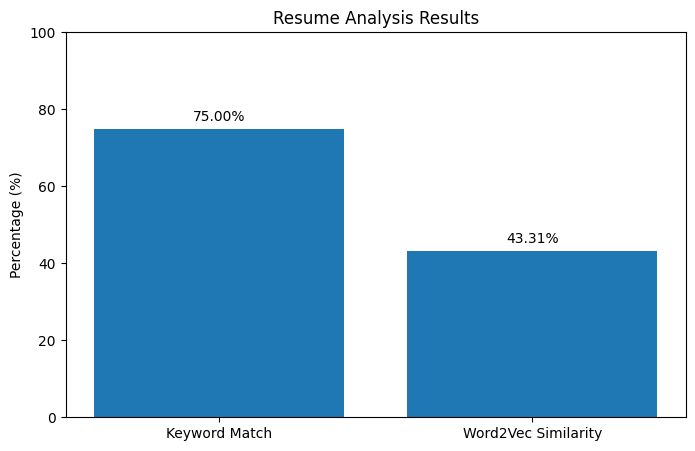

In [ ]:
import matplotlib.pyplot as plt


labels = ["Keyword Match", "Word2Vec Similarity"]
values = [
    match_percentage,
    similarity_score * 100
]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)

plt.ylim(0, 100)
plt.ylabel("Percentage (%)")
plt.title("Resume Analysis Results")


for i, value in enumerate(values):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")

plt.show()

In [ ]:
from google.colab import files
import PyPDF2


uploaded = files.upload()

print("Resume uploaded successfully!")

Saving TSA resume.pdf to TSA resume (1).pdf
Resume uploaded successfully!


In [ ]:

pdf_filename = list(uploaded.keys())[0]

pdf_file = open(pdf_filename, "rb")


pdf_reader = PyPDF2.PdfReader(pdf_file)

resume_text = ""

for page in pdf_reader.pages:
    text = page.extract_text()

    if text:
        resume_text += text + "\n"

pdf_file.close()

print("Resume text extracted successfully!")
print("\n----- RESUME TEXT PREVIEW -----\n")
print(resume_text[:2000])

Resume text extracted successfully!

----- RESUME TEXT PREVIEW -----




In [ ]:
job_description = input("Enter the Job Description:\n")

print("\nJob Description received successfully!")

In [ ]:
from gensim.models import Word2Vec

# Combine actual resume and job description
combined_text = resume_text + " " + job_description

# Convert text into words
words = re.findall(r'\b[a-zA-Z]+\b', combined_text.lower())

# Create training data
sentences = [words]

# Train Word2Vec model
word2vec_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    seed=42
)

print("Word2Vec model trained using actual Resume + Job Description!")